[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AU-s-Elevforbund/gymnasiearbete/blob/main/01-exoplanetens-storlek/01-exoplanetens-storlek.ipynb)

# Hur stor är exoplaneten?

Hämta en ljuskurva från rymdteleskopet TESS, hitta planetpassagen och räkna ut planetens radie utifrån hur mycket stjärnan dämpas.

**Data:** Öppen data (TESS)
**Bibliotek:** Lightkurve: ljuskurvor från TESS och Kepler

*Det här exemplet är under uppbyggnad.*

## Frågeställning

Hur stor är exoplaneten kepler 570b och hur långt bort från sin stjärna befinner den sig?

## Bakgrund

I detta projektet kommer vi undersöka exoplaneten kepler 186b med data från NASA:s exoplanet jägare Kepler. Vi kommer bestämma planetens omlopps tid och dess radie. Detta kommer göras med hjälp av transit fotometri.

### Vad är transit fotometri
I vissa fall så kan det vara så att omloppsbanan för en planet ligger så att planeten passerar framför sin stjärna, under en sådan passage kommer planeten att blockera en viss mängd av stjärnans ljus och detta kan vi mäta. Mäter vi en stjärnas ljusstyrka under en sådan passage kommer vi se hur mycket ljus planeten blockerar (transit djup), hur länge och hur ofta. Utifrån det kan vi sedan beräkna planetens radie, omloppstid och ban radie.

### Radie
Planetens radie kan vi beräkna med hjälp av en simpel ekvation och lite information om stjärnan. Det är nämligen så att transig djupet är lika med kvadraten av kvoten mellan planetens radie och stjärnans radie.

$$
\text{djup} = \left ( \frac{R_p}{R_s}\right ) ^2
$$

### Period
Omlopps perioden får vi direkt från datan genom att göra ett periodogram. Periodogramet är en graf med period på x-axeln och power på y-axeln. Power kan man säga är ett betyg på hur bra en viss period passar datan. För exoplaneter används ofta en metod som heter "Box Least Squares" eller bls, detta är en metod som är baserad på en låd modell alltså en modell som ser ut som en låda. En låd modell har fyra parametrar, som i bilden är utmärkta. För att ta fram periodogramet varieras alla dessa fyra parametetrar och varje kombination får ett betyg baserat på hur väl de passar datan. [Läs med om BLS](https://docs.astropy.org/en/stable/timeseries/bls.html).

![BLS modell](https://docs.astropy.org/en/stable/_images/bls-1.png)

### Ban radie

Ban radien får vi genom att använda Keplers tredje lag.

$$
\frac{a^3}{T^2} = \frac{G(M+m)}{4\pi^2} \approx \frac{GM}{4\pi^2} \Rightarrow a = \left (\frac{GMT^2}{4\pi^2} \right )^{1/3}
$$

Här är a banradien, T perioden, G gravitations konstanten, M stjärnans massa och m planetens massa. Förenklingen som görs är att vi försummar planetens massa då den är så liten i jämförelse med stjärnans massa.

## Förberedelser

Kör cellen nedan för att installera det som inte redan finns i Google Colab.

In [1]:
%pip install -q lightkurve oktopus autograd

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import lightkurve as lk
from astropy import units as u
from astropy import constants as const

## Hämta data

Vi börjar med att hämta datan. Biblioteket lightkurve som vi använder för analysen kan hämta data direkt från de öppna arkiv som har hand om TESS och KEPLER data, i detta fallet är det MAST science arkive. Den första raden gör alltså en sökning efter data på stjärnan Kepler-186 som laddats upp av Kepler teleskopet och som tagits med lång exponerings tid. Rad två laddar ner all denna datan från arkivet.

In [3]:
sök_resultat = lk.search_lightcurve('Kepler-570', author='Kepler', cadence='long')
lc_samling = sök_resultat.download_all()

## Analys

Vi börjar med att titta på datan vi laddat ner. I plotten nedan är varje färgad linje en observations runda. På x-axeln har vi tid i Barycentrisk Kepler Julianskt Datum, vilket är ett sätt att mäta tid i antal dagar från en specifik startpunkt för att man ska slippa hålla på med skott år och månader osv. På x-axeln har vi Flux i elektroner per sekund, ett mått på hur ljusstark stjärnan är. Det blir elektroner per sekund eftersom fotoner görs om till elektroner i teleskopters detektor.

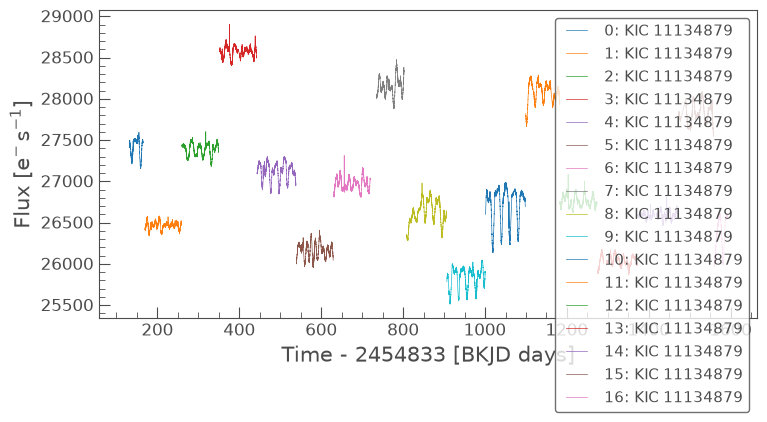

In [16]:
lc_samling.plot()
plt.show()

Nu behöver vi ta alla dessa olika observationer och kombinera dem till en enda långa tidsserie. Det gör vi genom att normera varje kort serie för sig och sedan sy ihop dem.

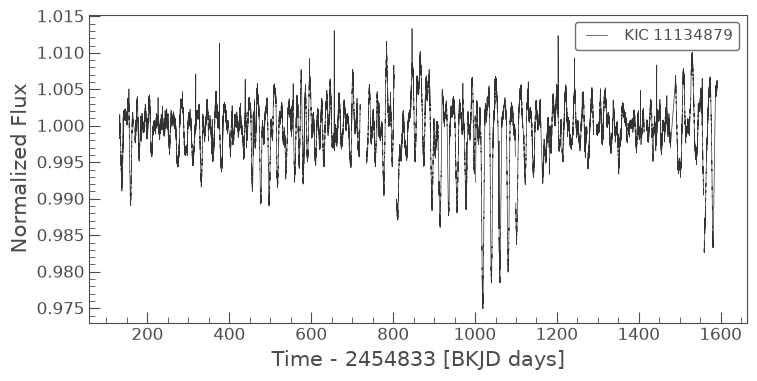

In [7]:
lc_stitch = lc_samling.stitch()
lc_stitch.plot()
plt.show()

Efter att vi sytt ihop alla observations rundor så tar vi bort avvikande värde, dessa kan bero på många saker t.ex instument fel. 

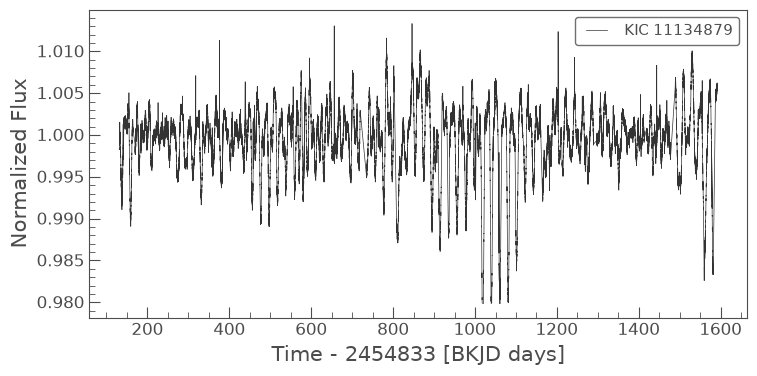

In [17]:
lc_outliers = lc_stitch.remove_outliers()
lc_outliers.plot()
plt.show()

När de avvikande punkterna är borta vill vi plocka bort eventuella långsamma trender som finns i datan. I detta fallet kan vi se att ljusstyrkan för stjärnan varierar ganska kraftigt så vi använder något som heter ett Savitsky-Golay filter som använder ett rörligt fönster för att plocka upp trender och sedan plockar vi helt enkelt bort trenderna.

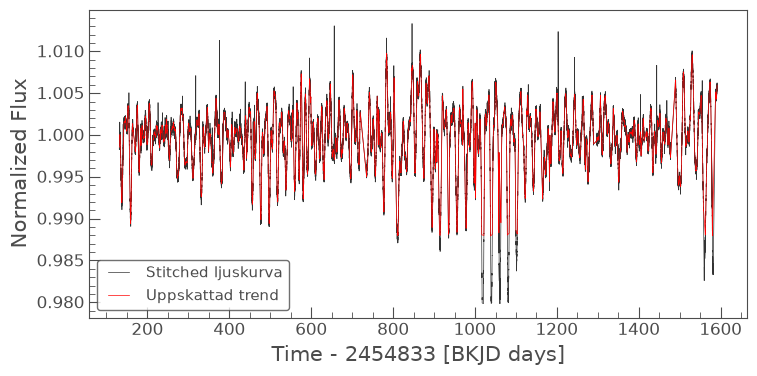

In [ ]:
# Flatten igen, men spara trenden
flat_lc, trend_lc = lc_outliers.flatten(return_trend=True, window_length=101)

# Skapa en figur för att jämföra den oplattade kurvan med trenden
ax = lc_outliers.plot(label='Stitched ljuskurva')
trend_lc.plot(ax=ax, color='red', linewidth=0.5, label='Uppskattad trend')
plt.show()


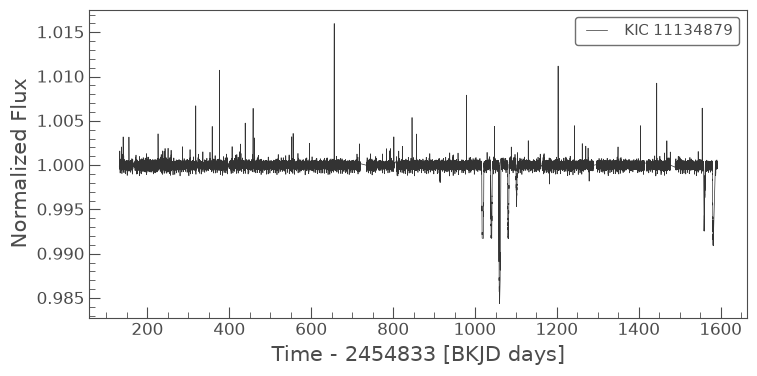

In [10]:
flat_lc.plot()
plt.show()

När trenderna är borta har vi äntligen data vi kan göra periodogram med. Vi börjar med att definera ett sökfönster och hur många olika perioder vi vill testa. Sedan gör vi periodogramet med lightkurves inbyggda version, plottar det och skriver ut de bästa värdena på modell parametrarna. 

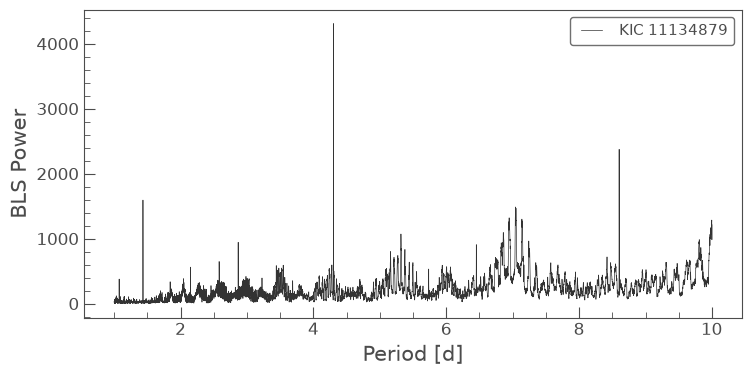

Period: 4.30 d
Epoch: 133.6171167305333
Djup: 0.05 %


In [22]:
perioder = np.linspace(1, 10, 10000)
periodogram = flat_lc.to_periodogram(method='bls', period=perioder, frequency_factor=5000)
periodogram.plot()
plt.show()
period_best = periodogram.period_at_max_power
epoch_best = periodogram.transit_time_at_max_power
depth_best = periodogram.depth_at_max_power
print(f'Period: {period_best:.2f}')
print(f'Epoch: {epoch_best}')
print(f'Djup: {depth_best*100:.2f} %')

För att kolla så att perioden med högst power i periodogrammet stämmer överens med en transit viker vi datan och tittar på den. 

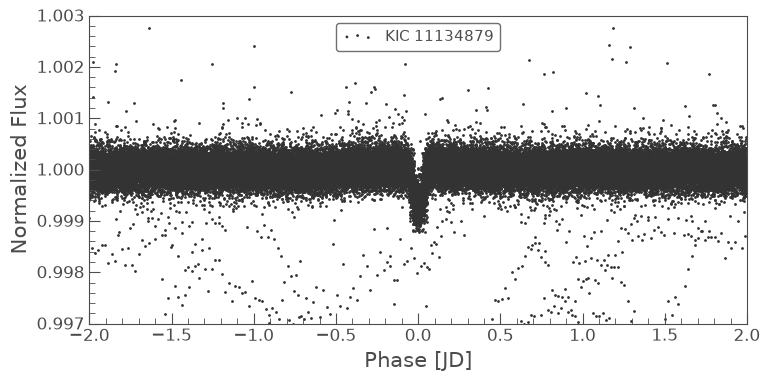

In [12]:
ax = flat_lc.fold(period=period_best, epoch_time=epoch_best).scatter()
ax.set_xlim(-2, 2);
ax.set_ylim(0.997, 1.003);
plt.show()

Det där är en tydlig signal och antar vi att det är en planet kan vi med formlerna från bakgrunde räkna ut planet radien och ban radien. 

In [13]:
R_star = 0.9103492 * u.R_sun
M_star = 0.930 * u.M_sun

R_planet = np.sqrt(depth_best * R_star**2)
a = ((const.G * M_star * period_best**2)/(4*np.pi**2))**(1/3)

print(f'Planet radius: {R_planet.to(u.R_earth):.2f}')
print(f'Planet distance: {a.to(u.AU):.2f}')

Planet radius: 2.15 earthRad
Planet distance: 0.05 AU


## Prova själv

Testa gärna andra stjärnor du kan hitta hela nasas exoplanet arkiv [här](https://exoplanetarchive.ipac.caltech.edu/). För att kolla på ett annat system är det bara att ändra vad du söker efter i rade med sök_resultat variabeln. 

## Bygg vidare

För att göra detta till ett helt gymnasiearbete kan du:
* Skriva ett program för att automatiskt gå igenom data och se om den hittar planeter
* Ta in mer data t.ex spektra för stjärnan och använda Radial velocity metoden för att väga planeten, ta reda på densiteten och klassificera den. 
* Kolla på system med mer än en planet och se hur man kan hitta fler planeter i samma system

Detta exempel saknar också helt diskussioner kring fel marginaler, hur vi kan vara säkra på att detta är en planet, vad det är för typ av planet och en massa annat.

## Källor

Detta exemplet bygger på ett exempel från lightkurves dokumentation som finns [här.](https://lightkurve.github.io/lightkurve/tutorials/3-science-examples/exoplanets-identifying-transiting-planet-signals.html)